# TP 1 — Pillow : prise en main

**Objectifs**

- Charger, inspecter et sauvegarder une image avec Pillow.
- Convertir entre modes (RGB, niveaux de gris, HSV).
- Appliquer des transformations géométriques (redimensionnement, rotation, recadrage).
- Utiliser les filtres `ImageFilter` et les ajustements `ImageEnhance`.
- Construire une planche-contact 3×3 de miniatures.

**Durée indicative : 50 minutes.**

Source de données : pour rester auto-suffisant, on s'appuie sur les images embarquées de scikit-image (`skimage.data`). Toute photo locale au format JPEG/PNG fait aussi l'affaire.

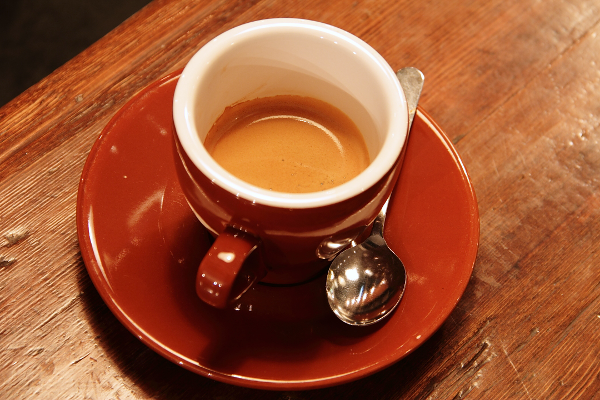

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter
from skimage import data

# On part d'une photo couleur fournie par skimage : 'coffee' (400x600, RGB).
img = Image.fromarray(data.coffee())
img

## Exercice 1 — Inspection

Affichez les propriétés de l'image : taille `(largeur, hauteur)`, mode, format (probablement `None` ici car l'image vient d'un tableau, pas d'un fichier).

Sauvegardez ensuite l'image dans le fichier `coffee.jpg` puis rechargez-la et vérifiez que le champ `format` est désormais renseigné.

In [2]:
# TODO : afficher size, mode, format

# TODO : sauvegarder en JPEG, recharger, afficher le format

## Exercice 2 — Conversion de modes et canaux

Produisez trois variantes de l'image :

1. `img_gray` en niveaux de gris (mode `"L"`).
2. `img_hsv` en HSV.
3. `img_bw` en binaire (mode `"1"`).

Affichez les trois côte à côte avec Matplotlib (n'oubliez pas `cmap="gray"` pour les images mono-canal).

**Bonus — manipuler les canaux** : utilisez `img.split()` pour récupérer les 3 canaux R, G, B sous forme d'images en niveaux de gris, puis recomposez avec `Image.merge("RGB", ...)` en **échangeant les canaux R et B** (le résultat aura une dominante bleue à la place du rouge). Affichez l'original et la version « R↔B » côte à côte.

<details>
<summary>💡 Coup de pouce</summary>

- `img.convert("L")` produit une image **mono-canal** : pensez à `cmap="gray"` à l'affichage.
- `img.convert("HSV")` reste à 3 canaux mais ce ne sont plus R, G, B : les afficher tel quel donnera des couleurs « bizarres », c'est normal.
- **Bonus** : `img.split()` renvoie un **tuple** `(r, g, b)` de 3 images en mode `"L"`. `Image.merge("RGB", (b, g, r))` recompose en échangeant les rôles. Pas besoin de transformer les canaux : on se contente de changer l'ordre du tuple.

</details>

In [3]:
# TODO : conversions L, HSV, 1

# TODO : affichage côte à côte

# Bonus : split / merge avec échange R↔B
# r, g, b = img.split()
# img_rb_swap = Image.merge("RGB", (b, g, r))
# affichage original vs swap

## Exercice 3 — Transformations géométriques

À partir de l'image originale, produisez :

- une version redimensionnée à 200×150 (`resize`),
- une miniature de taille maximale 128 px préservant le ratio (`thumbnail`),
- une rotation de 30° (avec `expand=True` pour ne pas couper l'image),
- un recadrage central de 200×200 pixels (à vous de calculer les bornes).

Affichez les quatre résultats.

<details>
<summary>💡 Coup de pouce</summary>

- Pour `crop`, la box est `(left, top, right, bottom)` en pixels. Pour un crop **centré** 200×200, calculez d'abord le centre : `cx, cy = w // 2, h // 2`, puis `box = (cx - 100, cy - 100, cx + 100, cy + 100)`.
- `thumbnail` modifie l'image **en place** (pas de retour) et **préserve le ratio**. Utilisez `img.copy()` si vous voulez garder l'original.
- `rotate(30, expand=True)` agrandit le cadre pour ne pas couper les coins.

</details>

In [4]:
# TODO

## Exercice 4 — Filtres et ajustements

Appliquez à l'image :

- un flou gaussien de rayon 4 (`ImageFilter.GaussianBlur`),
- une détection de bords (`ImageFilter.FIND_EDGES`),
- un masque flou inverse (`ImageFilter.UnsharpMask`).

Puis, avec `ImageEnhance`, créez :

- une version désaturée (facteur de couleur 0),
- une version avec contraste ×1.5.

Affichez les 5 résultats sur une grille 2×3 (la 6ᵉ case affichera l'originale).

<details>
<summary>💡 Coup de pouce</summary>

- Les filtres s'appliquent via `img.filter(ImageFilter.GaussianBlur(radius=4))` (le filtre est une **instance**, pas une fonction directe).
- `ImageEnhance` a une syntaxe en deux temps : `ImageEnhance.Color(img).enhance(0)` pour désaturer (facteur 0 = noir & blanc), `ImageEnhance.Contrast(img).enhance(1.5)` pour amplifier le contraste.

</details>

In [5]:
# TODO

## Exercice 5 — Planche-contact 3×3

Récupérez **neuf images** différentes de `skimage.data` (par exemple `astronaut`, `coffee`, `chelsea`, `cat`, `rocket`, `coins`, `camera`, `hubble_deep_field`, `immunohistochemistry`).

Construisez une **planche-contact** : une grille 3×3 de miniatures carrées de 128×128 pixels chacune, le tout dans une seule image Pillow finale de 384×384.

Indications :

1. Convertissez chaque image en RGB et redimensionnez-la à 128×128 (utilisez `resize` ; ce TP ne se préoccupe pas du ratio, l'écrasement est acceptable).
2. Créez une image vide `planche = Image.new("RGB", (384, 384))`.
3. Utilisez `planche.paste(vignette, (x, y))` pour coller chaque vignette à la bonne position.
4. Sauvegardez la planche en `planche_contact.png` et affichez-la.

Bonus : ajoutez un cadre blanc de 4 pixels entre les vignettes.

<details>
<summary>💡 Coup de pouce</summary>

- Boucle imbriquée sur la grille : `for i in range(3): for j in range(3): ...`
- Position de collage pour la vignette (i, j) : `(j * 128, i * 128)` (la colonne donne x, la ligne donne y).
- Penser à `vignette.convert("RGB")` avant `paste` si certaines images de `skimage.data` sont en niveaux de gris.
- **Bonus cadre blanc** : créez la planche avec un fond blanc et un pas légèrement plus grand : `(j * 132 + 4, i * 132 + 4)`.

</details>

In [6]:
# TODO